In [34]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [35]:
model = SimpleCNN()
model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

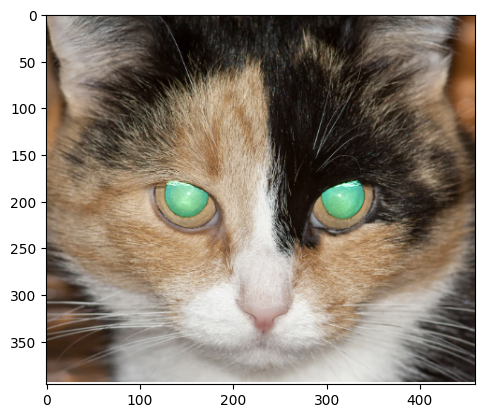

In [ ]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

img = Image.open('cat.png').convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = transform(img)

plt.imshow(img)

In [37]:
image.shape

torch.Size([3, 224, 224])

In [38]:
image = image.unsqueeze(0)
print(image.shape)

torch.Size([1, 3, 224, 224])


In [39]:
x = image

print("Input:", x.shape)

for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:15} -> {x.shape}")

Input: torch.Size([1, 3, 224, 224])
Conv2d          -> torch.Size([1, 32, 224, 224])
BatchNorm2d     -> torch.Size([1, 32, 224, 224])
ReLU            -> torch.Size([1, 32, 224, 224])
MaxPool2d       -> torch.Size([1, 32, 112, 112])
Conv2d          -> torch.Size([1, 64, 112, 112])
BatchNorm2d     -> torch.Size([1, 64, 112, 112])
ReLU            -> torch.Size([1, 64, 112, 112])
MaxPool2d       -> torch.Size([1, 64, 56, 56])


In [40]:
x.shape

torch.Size([1, 64, 56, 56])

Text(0.5, 1.0, 'Feature Map of First Filter')

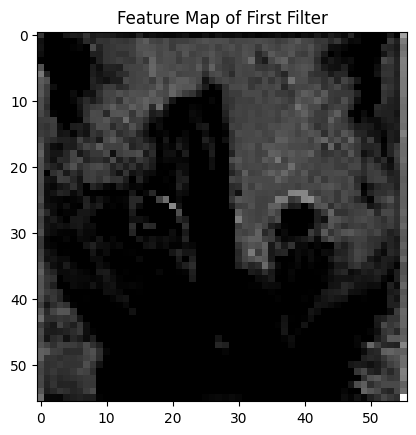

In [41]:
plt.imshow(x[0,0].detach().numpy(), cmap='gray')
plt.title('Feature Map of First Filter')

Text(0.5, 1.0, 'Feature Map of Tenth Filter')

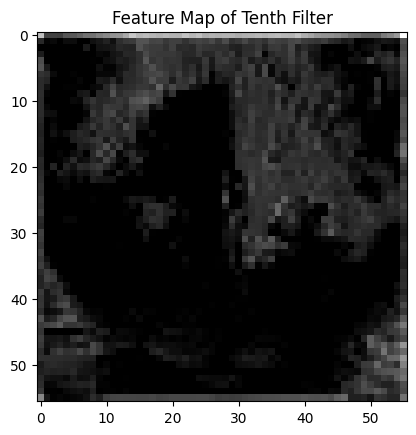

In [ ]:
plt.imshow(x[0,10].detach().numpy(), cmap='gray')
plt.title('Feature Map of Tenth Filter')

Text(0.5, 1.0, 'Feature Map of Twenty-Fifth Filter')

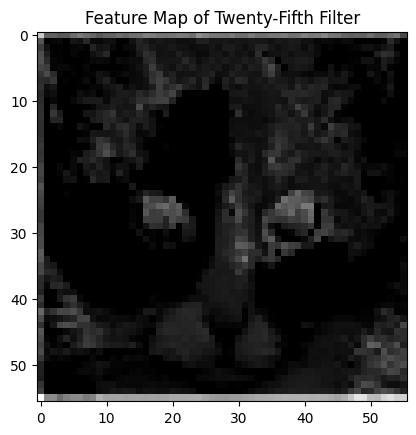

In [43]:
plt.imshow(x[0,25].detach().numpy(), cmap='gray')
plt.title('Feature Map of Twenty-Fifth Filter')


In [44]:
for layer in model.classifier:
    x = layer(x)
    print(f"{layer.__class__.__name__:20} -> {x.shape}")

AdaptiveAvgPool2d    -> torch.Size([1, 64, 1, 1])
Flatten              -> torch.Size([1, 64])
Linear               -> torch.Size([1, 10])


In [45]:
gap = model.classifier[0](model.features(image))
gap = model.classifier[1](gap)

print(gap.shape)
print(gap)

torch.Size([1, 64])
tensor([[0.6089, 0.6322, 0.5070, 0.5869, 0.6044, 0.6137, 0.5739, 0.6055, 0.5276,
         0.6193, 0.5900, 0.6110, 0.5110, 0.5646, 0.5930, 0.6403, 0.5762, 0.5357,
         0.5749, 0.6220, 0.5473, 0.5945, 0.5855, 0.5842, 0.5333, 0.6208, 0.5372,
         0.5248, 0.5811, 0.5864, 0.5639, 0.6349, 0.5438, 0.5635, 0.6410, 0.5705,
         0.5945, 0.7191, 0.5321, 0.5544, 0.5271, 0.5852, 0.5882, 0.6291, 0.6317,
         0.5981, 0.6018, 0.5387, 0.6041, 0.5388, 0.5885, 0.6056, 0.5478, 0.5426,
         0.5221, 0.5647, 0.5440, 0.5463, 0.5093, 0.5886, 0.5383, 0.5874, 0.6074,
         0.6030]], grad_fn=<ViewBackward0>)


In [46]:
output = model(image)

print(output)

tensor([[ 0.2552,  0.1817,  0.3702,  0.5651,  0.2875,  0.4012,  0.1206,  0.6972,
         -0.4957,  0.1071]], grad_fn=<AddmmBackward0>)


In [47]:
prob = torch.softmax(output, dim=1)
prob

tensor([[0.0964, 0.0896, 0.1082, 0.1315, 0.0996, 0.1116, 0.0843, 0.1500, 0.0455,
         0.0832]], grad_fn=<SoftmaxBackward0>)

In [48]:
prob.sum()

tensor(1., grad_fn=<SumBackward0>)

In [49]:
pred = torch.argmax(prob, dim=1)
pred

tensor([7])

In [51]:
def inspect_model(model, x):
    print(f"{'Input':20} {x.shape}")

    for layer in model.features:
        x = layer(x)
        print(f"{layer.__class__.__name__:20} {x.shape}")

    for layer in model.classifier:
        x = layer(x)
        print(f"{layer.__class__.__name__:20} {x.shape}")

    return x

In [52]:
output = inspect_model(model, image)

Input                torch.Size([1, 3, 224, 224])
Conv2d               torch.Size([1, 32, 224, 224])
BatchNorm2d          torch.Size([1, 32, 224, 224])
ReLU                 torch.Size([1, 32, 224, 224])
MaxPool2d            torch.Size([1, 32, 112, 112])
Conv2d               torch.Size([1, 64, 112, 112])
BatchNorm2d          torch.Size([1, 64, 112, 112])
ReLU                 torch.Size([1, 64, 112, 112])
MaxPool2d            torch.Size([1, 64, 56, 56])
AdaptiveAvgPool2d    torch.Size([1, 64, 1, 1])
Flatten              torch.Size([1, 64])
Linear               torch.Size([1, 10])
